In [1]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# ==================================================
# 1. TRANSFORMS
# ==================================================
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.03593449, 0.0138905, 0.05819073],
        std=[0.15817634, 0.07281315, 0.18924118]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.03593449, 0.0138905, 0.05819073],
        std=[0.15817634, 0.07281315, 0.18924118]
    )
])

# ==================================================
# 2. LOAD DATASETS
# ==================================================
def load_datasets(data_path, train_bs, val_bs, test_bs):
    train_dir = os.path.join(data_path, "train")
    val_dir   = os.path.join(data_path, "val")
    test_dir  = os.path.join(data_path, "test")

    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset   = datasets.ImageFolder(val_dir,   transform=val_transform)
    test_dataset  = datasets.ImageFolder(test_dir,  transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=train_bs, shuffle=True,  num_workers=4)
    val_loader   = DataLoader(val_dataset,   batch_size=val_bs,   shuffle=False, num_workers=4)
    test_loader  = DataLoader(test_dataset,  batch_size=test_bs,  shuffle=False, num_workers=4)

    n_classes = len(train_dataset.classes)
    return train_loader, val_loader, test_loader, n_classes



SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.6, inplace=False)
    (5): Linear(in_features=256, out_features=8, bias=True)
  )
)

[i] 

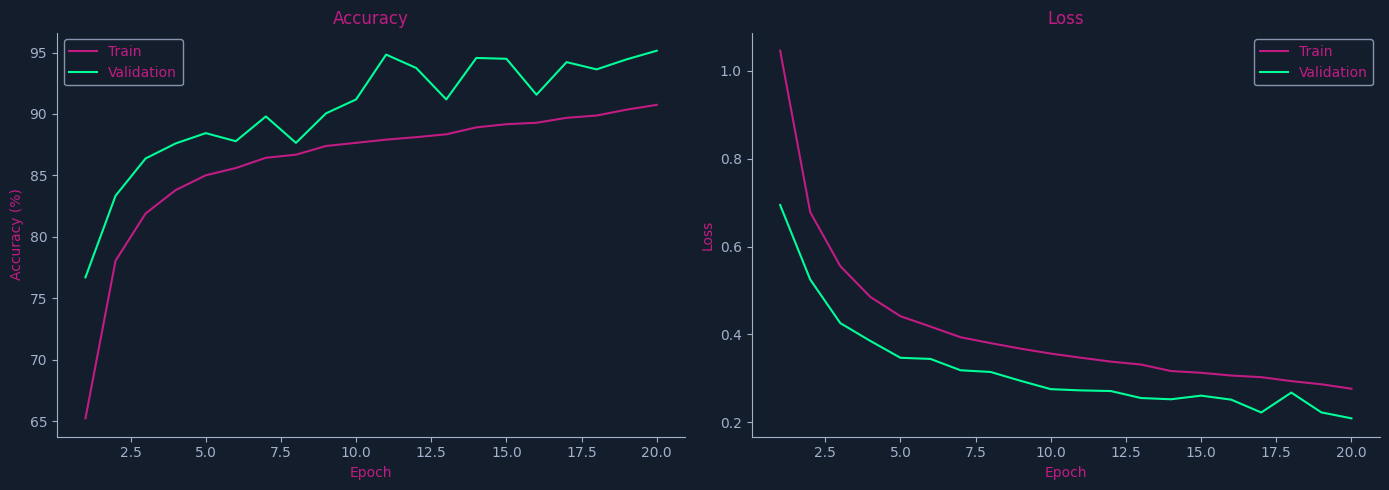

In [2]:
# ==================================================
# 3. MODEL — Small 2-block CNN
# ==================================================
class SmallCNN(nn.Module):
    """
    Lightweight 2-block CNN.

    Layer count:
      Block 1: Conv → BN → ReLU → MaxPool   (4 layers)
      Block 2: Conv → BN → ReLU → MaxPool   (4 layers)
      AdaptiveAvgPool                        (1 layer)
      Classifier: Flatten → Linear → BN →
                  ReLU → Dropout → Linear   (6 layers)
      Total: 15 layers
    """
    def __init__(self, n_classes: int):
        super(SmallCNN, self).__init__()

        self.features = nn.Sequential(
            # --- Block 1 ---
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),              # 64×64 → 32×32

            # --- Block 2 ---
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),              # 32×32 → 16×16
        )

        # Shrink spatial dims to 4×4 regardless of input size
        self.pool = nn.AdaptiveAvgPool2d((4, 4))  # 16×16 → 4×4

        self.classifier = nn.Sequential(
            nn.Flatten(),                          # 64×4×4 = 1024
            nn.Linear(64 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.6),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


# ==================================================
# 4. EARLY STOPPING
# ==================================================
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience  = patience
        self.best_loss = float("inf")
        self.counter   = 0
        self.stop      = False

    def check(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            print(f"    [EarlyStopping] No improvement {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True
                print("[!] Early stopping triggered")


# ==================================================
# 5. TRAINING
# ==================================================
def train(model, train_loader, val_loader, n_epochs, device,
          class_weights=None, verbose=False):

    model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4      # regularization
    )

    training_data  = {
        "train_accuracy": [], "train_loss": [],
        "val_accuracy":   [], "val_loss":   []
    }
    early_stopping = EarlyStopping(patience=5)

    for epoch in range(n_epochs):
        # ---- Train ----
        model.train()
        running_loss      = 0.0
        n_total, n_correct = 0, 0
        start_time        = time.time()

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted  = torch.max(outputs, 1)
            n_total      += labels.size(0)
            n_correct    += (predicted == labels).sum().item()
            running_loss += loss.item()

        train_acc  = 100.0 * n_correct / n_total
        train_loss = running_loss / len(train_loader)
        duration   = time.time() - start_time

        # ---- Validate ----
        model.eval()
        val_loss_total      = 0.0
        val_total, val_correct = 0, 0
        val_criterion       = nn.CrossEntropyLoss()

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs        = model(inputs)
                loss           = val_criterion(outputs, labels)

                _, predicted    = torch.max(outputs, 1)
                val_total      += labels.size(0)
                val_correct    += (predicted == labels).sum().item()
                val_loss_total += loss.item()

        val_acc  = 100.0 * val_correct / val_total
        val_loss = val_loss_total / len(val_loader)

        # ---- Record ----
        training_data["train_accuracy"].append(train_acc)
        training_data["train_loss"].append(train_loss)
        training_data["val_accuracy"].append(val_acc)
        training_data["val_loss"].append(val_loss)

        if verbose:
            print(
                f"[Epoch {epoch+1}/{n_epochs}] "
                f"Train: {train_acc:.2f}% / {train_loss:.4f} | "
                f"Val: {val_acc:.2f}% / {val_loss:.4f} | "
                f"Time: {duration:.1f}s"
            )

        # ---- Early stopping ----
        early_stopping.check(val_loss)
        if early_stopping.stop:
            break

    return training_data


# ==================================================
# 6. VALIDATE / EVALUATE / PREDICT
# ==================================================
def validate(model, val_loader, device):
    model.eval()
    n_total, n_correct = 0, 0
    running_loss       = 0.0
    criterion          = nn.CrossEntropyLoss()

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels  = inputs.to(device), labels.to(device)
            outputs         = model(inputs)
            loss            = criterion(outputs, labels)
            _, predicted    = torch.max(outputs, 1)
            n_total        += labels.size(0)
            n_correct      += (predicted == labels).sum().item()
            running_loss   += loss.item()

    return running_loss / len(val_loader), 100.0 * n_correct / n_total


def predict(model, data):
    model.eval()
    with torch.no_grad():
        output = model(data)
        _, predicted = torch.max(output.data, 1)
    return predicted


def evaluate(model, test_loader, device):
    model.to(device)
    model.eval()
    n_correct, n_total = 0, 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target  = data.to(device), target.to(device)
            predicted     = predict(model, data)
            n_total      += target.size(0)
            n_correct    += (predicted == target).sum().item()

    return round(100 * n_correct / n_total, 2)


# ==================================================
# 7. SAVE MODEL
# ==================================================
def save_model(model, path):
    model_scripted = torch.jit.script(model)
    model_scripted.save(path)


# ==================================================
# 8. PLOTTING
# ==================================================
def plot_overfit_check(training_data):
    pink        = "#C11C84"
    node_black  = "#141D2B"
    hacker_grey = "#A4B1CD"
    green       = "#00FF99"

    epochs = range(1, len(training_data["train_accuracy"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=node_black)

    # Accuracy
    ax1.plot(epochs, training_data["train_accuracy"], color=pink,  label="Train")
    ax1.plot(epochs, training_data["val_accuracy"],   color=green, label="Validation")
    ax1.set_title("Accuracy",      color=pink)
    ax1.set_xlabel("Epoch",        color=pink)
    ax1.set_ylabel("Accuracy (%)", color=pink)
    ax1.set_facecolor(node_black)
    ax1.tick_params(colors=hacker_grey)
    ax1.spines["bottom"].set_color(hacker_grey)
    ax1.spines["left"].set_color(hacker_grey)
    ax1.spines["top"].set_color(node_black)
    ax1.spines["right"].set_color(node_black)
    l1 = ax1.legend(facecolor=node_black, edgecolor=hacker_grey)
    plt.setp(l1.get_texts(), color=pink)

    # Loss
    ax2.plot(epochs, training_data["train_loss"], color=pink,  label="Train")
    ax2.plot(epochs, training_data["val_loss"],   color=green, label="Validation")
    ax2.set_title("Loss",   color=pink)
    ax2.set_xlabel("Epoch", color=pink)
    ax2.set_ylabel("Loss",  color=pink)
    ax2.set_facecolor(node_black)
    ax2.tick_params(colors=hacker_grey)
    ax2.spines["bottom"].set_color(hacker_grey)
    ax2.spines["left"].set_color(hacker_grey)
    ax2.spines["top"].set_color(node_black)
    ax2.spines["right"].set_color(node_black)
    l2 = ax2.legend(facecolor=node_black, edgecolor=hacker_grey)
    plt.setp(l2.get_texts(), color=pink)

    plt.tight_layout()
    plt.show()


# ==================================================
# 9. RUN EVERYTHING
# ==================================================
DATA_PATH        = r"C:\Users\lenovo LOQ\pfa2\Sorted"
N_EPOCHS         = 20
TRAIN_BATCH_SIZE = 32
VAL_BATCH_SIZE   = 32
TEST_BATCH_SIZE  = 32
MODEL_FILE       = "malware_smallcnn.pt"
device           = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
train_loader, val_loader, test_loader, n_classes = load_datasets(
    DATA_PATH, TRAIN_BATCH_SIZE, VAL_BATCH_SIZE, TEST_BATCH_SIZE
)

# Init model
model = SmallCNN(n_classes)
print(model)

# Train
print("\n[i] Starting Training...")
training_information = train(
    model, train_loader, val_loader,
    N_EPOCHS, device=device, verbose=True
)

# Evaluate
val_loss, val_acc = validate(model, val_loader, device)
test_acc          = evaluate(model, test_loader, device)
print(f"\n[i] Validation Accuracy : {val_acc:.2f}%")
print(f"[i] Test Accuracy       : {test_acc:.2f}%")

# Save
save_model(model, MODEL_FILE)

# Plot
plot_overfit_check(training_information)

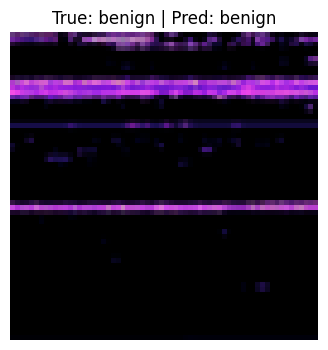

In [3]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_prediction(model, dataset, device):
    model.eval()

    # Pick a random image
    idx = random.randint(0, len(dataset) - 1)
    img, label = dataset[idx]

    # Get class names
    class_names = dataset.classes

    # Add batch dimension
    input_tensor = img.unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)

    pred_label = predicted.item()

    # Unnormalize for display
    mean = [0.03593449, 0.0138905, 0.05819073]
    std  = [0.15817634, 0.07281315, 0.18924118]

    img_display = img.clone()
    for t, m, s in zip(img_display, mean, std):
        t.mul_(s).add_(m)

    img_display = img_display.permute(1, 2, 0).cpu().numpy()

    # Plot
    plt.figure(figsize=(4,4))
    plt.imshow(img_display)
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred_label]}")
    plt.axis("off")
    plt.show()

# 👉 Use it
show_prediction(model, test_loader.dataset, device)

In [8]:
from fastapi import FastAPI, File, UploadFile
from PIL import Image
import torch
import torchvision.transforms as transforms
import io

# ===============================
# LOAD MODEL
# ===============================
MODEL_PATH = "malware_smallcnn.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.jit.load(MODEL_PATH)
model.to(device)
model.eval()

# ⚠️ Replace with your real class names
class_names = [
    "adware",
    "backdoor",
    "benign",
    "downloader",
    "spyware",
    "trojan",
    "virus",
    "worm"
]
# ===============================
# TRANSFORM (same as validation!)
# ===============================
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.03593449, 0.0138905, 0.05819073],
        std=[0.15817634, 0.07281315, 0.18924118]
    )
])

# ===============================
# APP
# ===============================
app = FastAPI()

@app.get("/")
def home():
    return {"message": "Model API is running 🚀"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    # Read image
    contents = await file.read()
    image = Image.open(io.BytesIO(contents)).convert("RGB")

    # Transform
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)

    pred_class = class_names[predicted.item()]

    return {
        "filename": file.filename,
        "prediction": pred_class
    }

In [7]:
!pip install python-multipart

  Using cached python_multipart-0.0.22-py3-none-any.whl.metadata (1.8 kB)
Using cached python_multipart-0.0.22-py3-none-any.whl (24 kB)
